#Prédiction des cas de leishmaniose dans la province de Ouarzazate 🦟

La maladie de leishmaniose est une maladie parasitaire infectueuse qui est souvant transmit par des phlébotomes (mouches de sande) des animaux aux humains. Pour lutter contre cette maladie, les chercheurs ont utilisé beaucoup des méthodes et des stratégies pour limiter son danger, souvant des techniques statistiques de prédiction. Ces techniques sont souvant trés utils pour informer les autorithés sanitaires de l'évolution de la maladie sur période spécifique et dans un endrois spécifique, mais ils ne peuvent souvant pas modéliser des tendances complexes de la maladies et les variations causés par d'autres facteurs climatiques et sociodémographiques. Notre objectif est de créer un modèle puissant qui exploite les capacités des modèles d’apprentissage profond pour prédire les cas de leishmaniose dans la province d’Ouarzazate en se basant sur des variables climatiques et des dépendances temporelles, fournissant ainsi une méthode beaucoup plus robuste et puissante pour surveiller la tendance de la maladie dans la province.

In [11]:
#importation des bibliothéques de travail
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
import requests
import warnings
warnings.filterwarnings("ignore")
#

In [ ]:
!pip install tensorflow==2.15.0
#

In [ ]:
!pip install shap
#

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


##1. Collecte des données et prétraitements initiales

Pour construire notre modéle, nous allons utiliser des données cliniques des cas signalé de la leishmaniose dans la province de Ouarzazate, qui seront notre variable dépendante qui représentra le nombre des cas mensuelles de leishmaniose dans la province. Les données ont été collecté depuis la base de données de Sidi Hsein.

In [13]:
#importation des données des cas confirmé de la leishmaniose dans la province
df=pd.read_excel("/content/drive/MyDrive/Prédiction des cas de leishmaniose dans la province de ouarzazate/DB leishmanioses  Ouarzazate 2018-2022.xlsx")
#

In [14]:
#selectionner les variables qu'on va utiliser
df=df[["Année","Commune ","Milieu","Sexe","Age en année","Date Diagnistic"]]
#

In [15]:
df.head()
#

,Année,Commune,Milieu,Sexe,Age en année,Date Diagnistic
0,2018,Ouarzazate,U,F,24.0,2017-12-27 00:00:00
1,2018,Ouarzazate,U,M,4.0,2017-12-27 00:00:00
2,2018,Ouarzazate,U,M,35.0,2018-01-02 00:00:00
3,2018,Ouarzazate,U,F,25.0,2018-01-02 00:00:00
4,2018,Ouarzazate,U,M,31.0,2018-01-05 00:00:00


In [16]:
#corriger les erreurs dans les dates
df["Date Diagnistic"].iloc[2219]="28-01-2021"
#

In [17]:
#transformer les dates en type Datetime
df["Date Diagnistic"]=pd.to_datetime(df["Date Diagnistic"])
#

In [18]:
df.head()
#

,Année,Commune,Milieu,Sexe,Age en année,Date Diagnistic
0,2018,Ouarzazate,U,F,24.0,2017-12-27
1,2018,Ouarzazate,U,M,4.0,2017-12-27
2,2018,Ouarzazate,U,M,35.0,2018-01-02
3,2018,Ouarzazate,U,F,25.0,2018-01-02
4,2018,Ouarzazate,U,M,31.0,2018-01-05


In [19]:
#extraire le mois de diagnostic
df['Mois']=df["Date Diagnistic"].dt.month
df["Mois"].iloc[0]=1
df['Mois'].iloc[1]=1
df.drop("Date Diagnistic",axis=1,inplace=True)
#

In [20]:
df.head()
#

,Année,Commune,Milieu,Sexe,Age en année,Mois
0,2018,Ouarzazate,U,F,24.0,1
1,2018,Ouarzazate,U,M,4.0,1
2,2018,Ouarzazate,U,M,35.0,1
3,2018,Ouarzazate,U,F,25.0,1
4,2018,Ouarzazate,U,M,31.0,1


In [21]:
#calculer les cas mensuelles de la leishmaniose dans la province
leish_cases=df.groupby(by=["Année","Mois"]).size().reset_index(name="Cases")
#

In [22]:
leish_cases.head()
#

,Année,Mois,Cases
0,2018,1,131
1,2018,2,146
2,2018,3,137
3,2018,4,30
4,2018,5,44


In [23]:
#construire un variable "Date" qui va représenter le mois et l'année de chaque nombre des cas de leishmaniose
leish_cases["Date"]=leish_cases["Année"].astype(str)+"-"+leish_cases["Mois"].astype(str)+"-1"
leish_cases["Date"]=pd.to_datetime(leish_cases["Date"])
leish_cases.set_index("Date",inplace=True)
leish_cases.columns=["Annee","Mois","Cases"]
#

In [24]:
leish_cases.head()
#

,Annee,Mois,Cases
Date,,,
2018-01-01,2018,1,131
2018-02-01,2018,2,146
2018-03-01,2018,3,137
2018-04-01,2018,4,30
2018-05-01,2018,5,44


In [25]:
#ajouter les cas mensuelles de leishmaniose de 2010 à 2017 pour avoir plus des données représentatives
leish_cases=pd.concat([pd.read_csv("/content/drive/MyDrive/Prédiction des cas de leishmaniose dans la province de ouarzazate/Modélisation/full_leish_data_2010-2022.csv").set_index("Date")[["Annee","Mois","Cases"]][:96],leish_cases],axis=0,ignore_index=False)
#

In [26]:
leish_cases.index=pd.to_datetime(leish_cases.index)
#

In [27]:
leish_cases.head()
#

,Annee,Mois,Cases
Date,,,
2010-01-01,2010,1,71
2010-02-01,2010,2,54
2010-03-01,2010,3,48
2010-04-01,2010,4,20
2010-05-01,2010,5,17


> Aprés transformation des données cliniques en un variable qui représente les cas mensuelles de la leishmaniose dans la province, il est maintenant temps de collecter et préparer nos données climatiques

In [28]:
#preparing the data
gdf = gpd.read_file('/content/drive/MyDrive/Prédiction des cas de leishmaniose dans la province de ouarzazate/geo_data_communes.geojson')
gdf["centroid_lon"]=gdf["geometry"].centroid.x
gdf["centroid_lat"]=gdf["geometry"].centroid.y
gdf_data=gdf[["ADM4_FR","centroid_lon", "centroid_lat"]]
gdf_data.columns=["commune","lon","lat"]
# Define a function to fetch data from the API
# Define an asynchronous function to fetch data from the API
def fetch_data(lat, lon, start_date, end_date):
    url = "https://power.larc.nasa.gov/api/temporal/daily/point"
    params = {
        "start": start_date,
        "end": end_date,
        "latitude": lat,
        "longitude": lon,
        "parameters": "RH2M,T2M_MIN,WS2M,GWETTOP,ALLSKY_SFC_UVB",
        "community": "AG",
        "format": "JSON"
    }
    response = requests.get(url, params=params)
    data = response.json()
    parameters = data['properties']['parameter']
    df = pd.DataFrame(parameters)
    df.index = pd.to_datetime(df.index)
    monthly_data = df.resample('M').mean()
    return monthly_data

# Prepare data
start_date = "20100101"
end_date="20221201"
lat_lon_data = gdf_data.set_index("commune")[["lat", "lon"]].iloc[:4]

# Fetch data in parallel
df_climat = pd.DataFrame()
for lat, lon in lat_lon_data.values:
    df = fetch_data(lat, lon, start_date, end_date)
    df_climat = pd.concat([df_climat, df], axis=0)
df_climat.reset_index(inplace=True)
df_climat["index"]=df_climat["index"].apply(lambda x : x.replace(day=1))
df_climat.set_index("index",inplace=True)
df_climat["Annee"]=df_climat.index.year
df_climat["Mois"]=df_climat.index.month
df_climat=df_climat.groupby(["Annee","Mois"],as_index=False).mean()
df_climat['Date']=pd.to_datetime(df_climat["Annee"].astype(str)+"-"+df_climat["Mois"].astype(str)+"-1")
def fix_negative_values_1(x) :
        if x<0 :
            return 0.3031823224712149
        else :
            return x
def fix_negative_values_2(x) :
      if x<0 :
          return 0.3340191676139952
      else :
          return x

df_climat["GWETTOP"]=df_climat["GWETTOP"].apply(fix_negative_values_1)
df_climat["ALLSKY_SFC_UVB"]=df_climat["ALLSKY_SFC_UVB"].apply(fix_negative_values_2)
df_climat.columns=["Annee","Mois","RH2M","TMP_MIN","WS2M","SOIL_W","UVB","Date"]
df_climat.set_index("Date",inplace=True)
#

In [29]:
df_climat.head()
#

,Annee,Mois,RH2M,TMP_MIN,WS2M,SOIL_W,UVB
Date,,,,,,,
2010-01-01,2010,1,56.027903,1.491210,3.081129,0.477258,0.011129
2010-02-01,2010,2,65.620268,3.374732,3.726786,0.560982,0.017500
2010-03-01,2010,3,53.389516,4.544516,3.462581,0.563629,0.027177
2010-04-01,2010,4,47.284917,8.338000,2.708500,0.445083,0.033250
2010-05-01,2010,5,39.770081,8.938145,3.730806,0.328548,0.038306


Maintenant il est temps de merge les deux dataframes pour obtenir une matrice qui représente les données finales

In [30]:
df_climat["Cases"]=leish_cases["Cases"].values
df_final=df_climat.copy()
#

In [31]:
df_final.head()
#

,Annee,Mois,RH2M,TMP_MIN,WS2M,SOIL_W,UVB,Cases
Date,,,,,,,,
2010-01-01,2010,1,56.027903,1.491210,3.081129,0.477258,0.011129,71
2010-02-01,2010,2,65.620268,3.374732,3.726786,0.560982,0.017500,54
2010-03-01,2010,3,53.389516,4.544516,3.462581,0.563629,0.027177,48
2010-04-01,2010,4,47.284917,8.338000,2.708500,0.445083,0.033250,20
2010-05-01,2010,5,39.770081,8.938145,3.730806,0.328548,0.038306,17


##2. Construction du modéle

Pour proposer une solution, nous avons construit un modéle hybride ConvBiLSTM qui combine la puissance des couches convolutifs dans l'extraction des caractéristiques et l'efficacité des couches BiLSTM dans le traitement des séquances temporelles.

In [ ]:
df_final=pd.read_csv("/content/drive/MyDrive/Prédiction des cas de leishmaniose dans la province de ouarzazate/Modélisation/full_leish_data_2010-2022.csv").set_index("Date")

In [ ]:
def get_season(month):
    if month in [12, 1, 2]:
        return 'Hiver'
    elif month in [3, 4, 5]:
        return 'Printemps'
    elif month in [6, 7, 8]:
        return 'Été'
    else :
        return 'Automne'
df_final["saison"]=df_final["Mois"].apply(get_season)

In [ ]:
df_final.head()

,Annee,Mois,RH2M,TMP_MIN,TMP_MAX,WS2M,WS10M,WD10M,WD2M,UVA,UVB,CLOUD_AMT,SOIL_M,SOIL_W,SOIL_RW,PRECT_TOTAL,SURFACE_P,SH2M,Cases,saison
Date,,,,,,,,,,,,,,,,,,,,
2010-01-01,2010,1,58.067647,-10.09,25.55,2.966471,4.247059,311.408235,311.491765,8.597647,0.148824,36.217647,0.527647,0.522941,0.534118,40.324706,83.640588,3.928235,71,Hiver
2010-02-01,2010,2,67.925294,-5.69,26.46,3.704706,5.248235,274.142353,273.551765,9.837059,0.193529,54.170588,0.591765,0.614706,0.604706,83.442941,83.284706,5.432353,54,Hiver
2010-03-01,2010,3,55.660000,-2.11,29.61,3.304118,4.689412,289.415294,288.811765,13.687647,0.314118,42.922941,0.602941,0.616471,0.621765,29.156471,83.697059,4.890000,48,Printemps
2010-04-01,2010,4,49.796471,0.37,32.36,2.674118,3.782353,256.629412,250.105882,16.078824,0.385294,47.584706,0.518824,0.485294,0.527059,1.240588,83.464118,5.765882,20,Printemps
2010-05-01,2010,5,41.630000,1.15,34.27,3.589412,4.928235,316.550000,313.687647,18.395882,0.453529,32.672353,0.462941,0.368824,0.466471,0.310000,83.564118,4.973529,17,Printemps


In [ ]:
par_saison=df_final.groupby(["Annee","saison"],as_index=False)["Cases"].sum()

In [ ]:
import plotly.express as px
px.bar(par_saison, x='Annee', y='Cases', color='saison', barmode='group',
             labels={'Annee': 'Année', 'Cases': 'Nombre des cas', 'saison': 'Saison'})

In [8]:
#preprocessing the data so it's compatible with Conv-BiLSTM architecture
def df_to_X_y(df,variables,window_size=12) :
    df_np=df[variables].values
    X=[]
    y=[]
    for i in range(len(df)-window_size) :
        row=[row for row in df_np[i:(i+window_size-1)]]
        row.append([df_np[i+window_size,0],df_np[i+window_size,1],df_np[i+window_size,2],
                    df_np[i+window_size,3],df_np[i+window_size,4],df_np[(i+window_size-1),-1]])
        label=df_np[i+window_size,-1]
        X.append(row)
        y.append(label)
    return np.array(X),np.array(y)

In [9]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import tensorflow as tf

In [32]:
#construire les matrices X et y pour entrainer notre modéle
X,y=df_to_X_y(df_final,variables=['RH2M','TMP_MIN','WS2M','SOIL_W','UVB',"Cases"])

In [33]:
X.shape,y.shape

((144, 12, 6), (144,))

In [34]:
model = tf.keras.models.load_model('/content/drive/MyDrive/Prédiction des cas de leishmaniose dans la province de ouarzazate/best_Conv-BiLSTM_0_8911_0_93_model.keras')

In [1]:
#construire l'architecture du modéle
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import *
from tensorflow.keras.losses import MeanSquaredError
from tensorflow.keras.metrics import RootMeanSquaredError
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint

model = Sequential()
model.add(Conv1D(filters=32, kernel_size=3, activation='linear',input_shape=(12, 6)))
model.add(Bidirectional(LSTM(40,return_sequences=True)))
model.add(Dropout(0.1))
model.add(Bidirectional(LSTM(60)))
model.add(Dense(1))
model.compile(loss=MeanSquaredError(),optimizer=Adam(learning_rate=0.02),metrics=[RootMeanSquaredError()])
model.summary()

/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                      │ (None, 10, 32)              │             608 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional (Bidirectional)        │ (None, 10, 80)              │          23,360 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 10, 80)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_1 (Bidirectional)      │ (None, 120)                 │          67,680 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │             121 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 91,769 (358.47 KB)

 Trainable params: 91,769 (358.47 KB)

 Non-trainable params: 0 (0.00 B)

In [35]:
#Préparer les données d'entrainement et de validation
X_train, X_val, y_train, y_val = X[:108], X[108:], y[:108], y[108:]

In [ ]:
history=model.fit(X_train,y_train,validation_data=(X_val,y_val),epochs=500)

Epoch 1/500
4/4 ━━━━━━━━━━━━━━━━━━━━ 8s 272ms/step - loss: 2291.4832 - root_mean_squared_error: 47.7349 - val_loss: 1683.2632 - val_root_mean_squared_error: 41.0276
Epoch 2/500
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 1417.4254 - root_mean_squared_error: 37.6083 - val_loss: 1433.9558 - val_root_mean_squared_error: 37.8676
Epoch 3/500
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 1128.0028 - root_mean_squared_error: 33.5533 - val_loss: 1333.4901 - val_root_mean_squared_error: 36.5170
Epoch 4/500
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 1075.6642 - root_mean_squared_error: 32.5612 - val_loss: 1324.4866 - val_root_mean_squared_error: 36.3935
Epoch 5/500
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 1261.5914 - root_mean_squared_error: 35.5122 - val_loss: 1330.0913 - val_root_mean_squared_error: 36.4704
Epoch 6/500
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 1108.0037 - root_mean_squared_error: 33.1750 - val_loss: 1326.2281 - val_root_mean_squared_error: 36.4174
Epoch 7/500
4/4

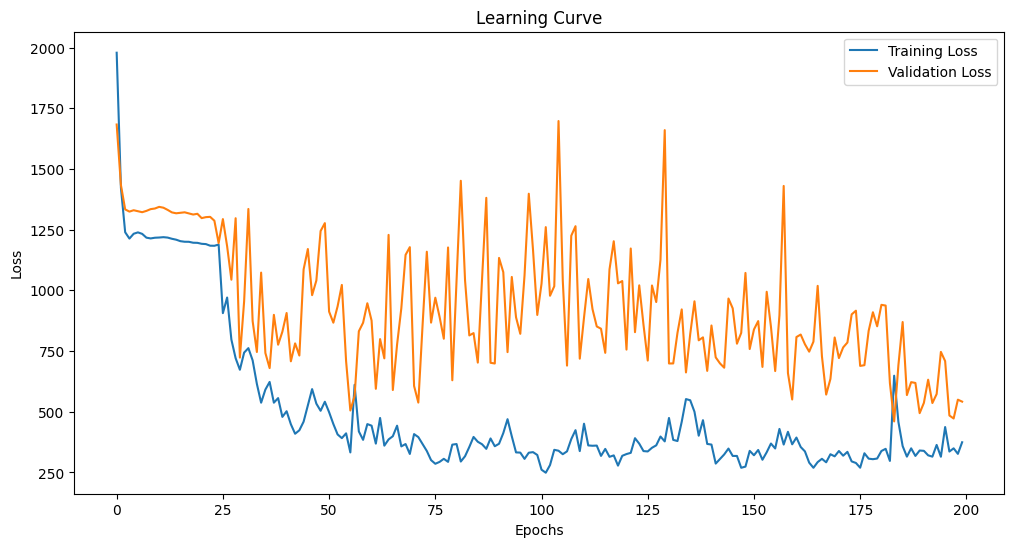

In [ ]:
#Visualiser la courbe d'entrainement
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'][:200], label='Training Loss')
plt.plot(history.history['val_loss'][:200], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Learning Curve')
plt.legend()

> Vue la courbe d'entrainement du modéle, il est évident que le modéle a réussi la modélisation des cas de leismaniose en 200 epochs et a trouvé les combainisons des variables climatiques qui expliquent la tendance de la maladie.

##3. Evaluation et Résultats du modéle

In [4]:
from tensorflow.keras.models import load_model

In [36]:
#model=load_model('/content/drive/MyDrive/Prédiction des cas de leishmaniose dans la province de ouarzazate/best_Conv-BiLSTM_0_8911_0_93_model.keras')
bestmodel=load_model('/content/drive/MyDrive/Prédiction des cas de leishmaniose dans la province de ouarzazate/best_Conv-BiLSTM_0_8911_0_93_model.keras')
# Check its architecture

In [37]:
X_train, X_test, y_train, y_test = X[:108], X[108:], y[:108], y[108:]

In [40]:
y_preds_train=model.predict(X_train).flatten()
y_preds_test=model.predict(X_test).flatten()

2/2 [==============================] - 0s 14ms/step


In [41]:
y_train_pred=pd.Series(y_preds_train,index=df_final["Cases"][12:120].index)
y_test_pred=pd.Series(y_preds_test,index=df_final["Cases"][120:].index)
y_preds=pd.concat([y_train_pred,y_test_pred],axis=0,ignore_index=False)

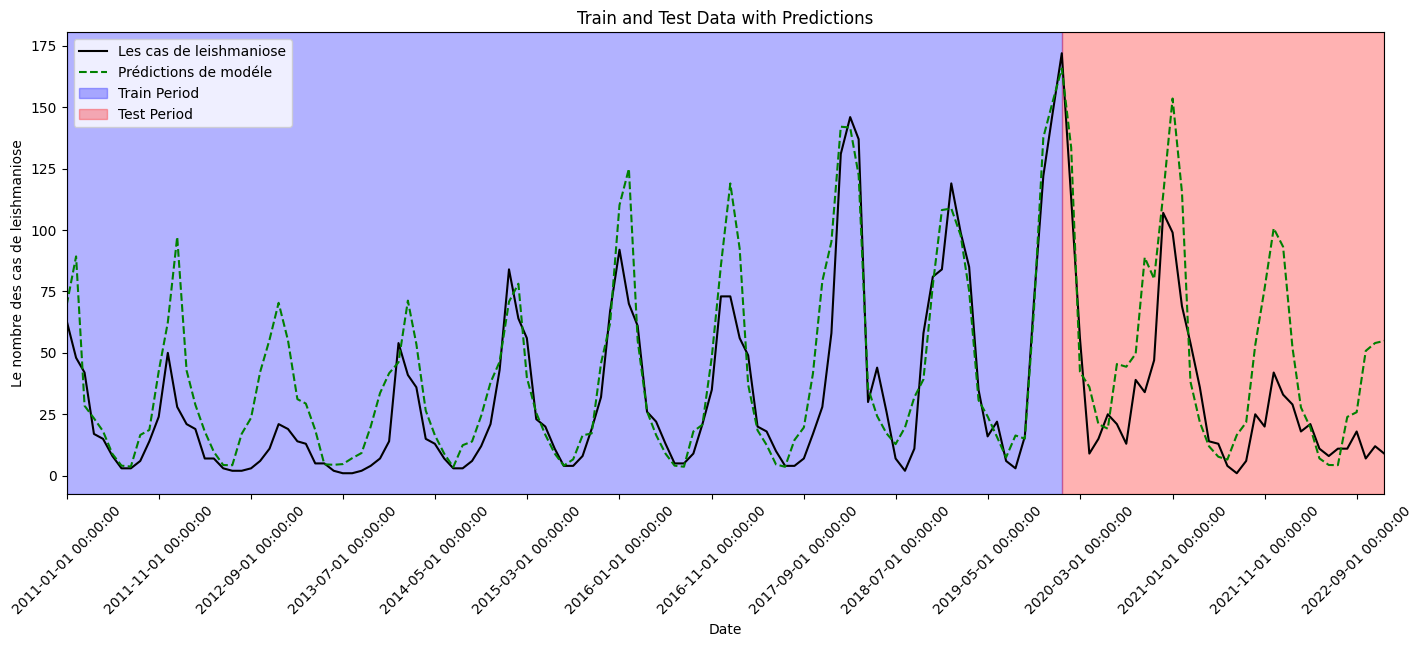

In [42]:
# Create a figure and axes
fig, ax = plt.subplots(figsize=(17,6))

# Plot the true values
ax.plot(df_final["Cases"][12:].index,df_final["Cases"][12:] , label='Les cas de leishmaniose', color='black')

# Plot the predicted values
ax.plot(y_preds, label='Prédictions de modéle', linestyle='--', color='green')

# Highlight the train and test areas
train_start, train_end = df_final["Cases"][12:121].index[0], df_final["Cases"][12:121].index[-1]
test_start, test_end = df_final["Cases"][120:].index[0], df_final["Cases"][120:].index[-1]
ax.axvspan(train_start, train_end, alpha=0.3, color='blue', label='Train Period')
ax.axvspan(test_start, test_end, alpha=0.3, color='red', label='Test Period')

ax.set_xticks(df_final["Cases"][12:].index[::10])
# Set x-axis tick labels to match the format of the dates
ax.set_xticklabels([date for date in df_final["Cases"][12:].index[::10]], rotation=45)

# Set x-axis limits to fit the dates
ax.set_xlim([df_final["Cases"][12:].index[0], df_final["Cases"][12:].index[-1]])

# Set labels and title
ax.set_xlabel('Date')
ax.set_ylabel('Le nombre des cas de leishmaniose')
ax.set_title('Train and Test Data with Predictions')
ax.legend();

###Evaluation du modéle

In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [ ]:
print("Test R2 Score :",r2_score(y_test,y_preds_test))

Test R2 Score : 0.8911448192864994


In [ ]:
print("Training R2 Score :",r2_score(y_train,y_preds_train))

Training R2 Score : 0.93834252647651


In [ ]:
print("Test MAE Score :",mean_absolute_error(y_test,y_preds_test))

Test MAE Score : 9.567959394719866


In [ ]:
print("Test RMSE Score :",np.sqrt(mean_squared_error(y_test,y_preds_test)))

Test RMSE Score : 11.995335360061798


In [ ]:
print("Train MAE Score :",mean_absolute_error(y_train,y_preds_train))

Train MAE Score : 5.696848849455516


In [ ]:
print("Train RMSE Score :",np.sqrt(mean_squared_error(y_train,y_preds_train)))

Train RMSE Score : 8.652696222665393


In [ ]:
print("Test MAPE Score :",(mean_absolute_error(y_test, y_preds_test) / np.mean(y_test)) * 100)

Test MAPE Score : 28.18711441979666


In [ ]:
print("Train MAPE Score :",(mean_absolute_error(y_train, y_preds_train) / np.mean(y_train)) * 100)

Train MAPE Score : 17.93759987583661


 ## 3. Explications des prédictions de modéle avec SHAP

In [ ]:
import shap
shap.initjs()

In [ ]:
X_interest=X[84:]
explainer=shap.GradientExplainer(model,X_interest)
shap_value=explainer.shap_values(X_interest)

###3.1. Explications locales des prédictions

In [ ]:
def shap_value_object(index,shap_value,timestep) :
    shap_values=shap_value[index:index+1][:,timestep,:].reshape((6))
    data=explainer(X_interest[index:index+1]).data[:,timestep,:].reshape(6)
    base_value=np.mean(model.predict(X_train))
    decalage={"0":12,"1": 11, "2" : 10, "3" : 9,"4":8,"5": 7, "6" : 6, "7" : 5,"8":4,"9": 3, "10" : 2, "11" : 1}
    shap_value_obj = shap.Explanation(values=shap_values,
                                        base_values=base_value,
                                        data=data,
                                        feature_names=['Humidité relative','Température minimale','Vitesse moyenne de vent','Humidité de sol','Intensité de rayon UVB',f"Les cas de leishmaniose à {decalage[str(timestep)]} décalages"])
                                        #feature_names=['RH2M',"TMP_MIN","WS2M","SOIL_W","UVB","Cases"])
    return shap_value_obj


In [ ]:
decalage_2={"0":12,"1": 11, "2" : 10, "3" : 9,"4":8,"5": 7, "6" : 6, "7" : 5,"8":4,"9": 3, "10" : 2, "11" : 0}

4/4 [==============================] - 0s 11ms/step


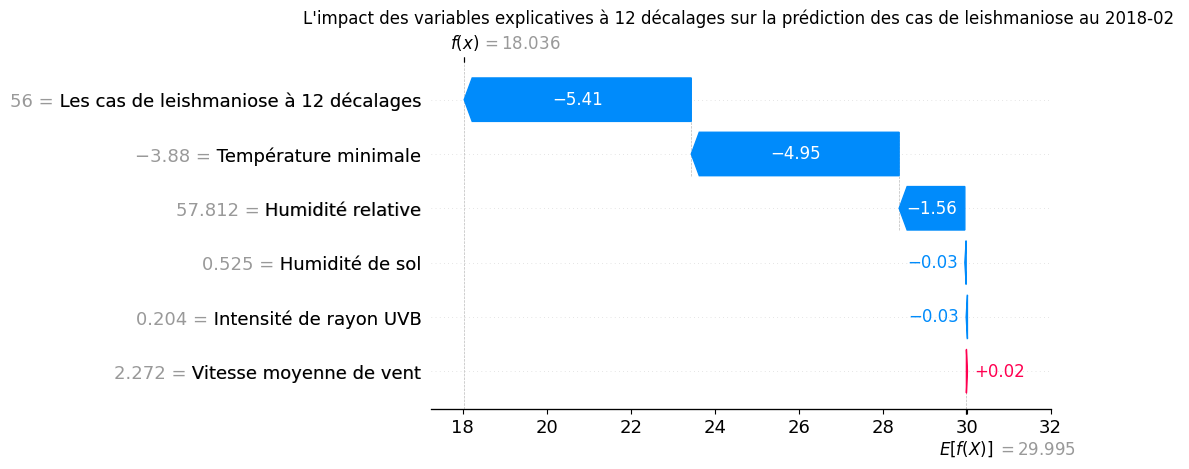

In [ ]:
index=1
timestep=0
plt.title(f"L'impact des variables explicatives à {decalage_2[str(timestep)]} décalages sur la prédiction des cas de leishmaniose au {df_final.iloc[84+index+12].name[:7]} ")
shap.plots.waterfall(shap_value_object(index,shap_value,timestep))

### 3.2. Explications globales des prédictions du modéle

In [ ]:
def shap_value_object_all(shap_value) :
    shap_values=shap_value.reshape((len(X_interest),12,6))
    shapley=[]
    for i in range(len(X_interest)) :
        shapley_i=[]
        for j in range(6) :
            shapley_i.append(shap_values[i,:,j].sum())
        shapley.append(shapley_i)
    shapley=np.array(shapley)
    ws=shapley[:,2].sum()
    soil_w=shapley[:,3].sum()
    uvb=shapley[:,4].sum()
    shapley[:,2]=ws
    shapley[:,3]=soil_w*2
    shapley[:,4]=uvb*2
    data=explainer(X_interest).data[:,0,:].reshape((60,6))
    base_value=np.mean(model.predict(X_train))
    shap_value_obj = shap.Explanation(values=shapley,
                                        base_values=base_value,
                                        data=data,
                                        feature_names=['Humidité relative','Température minimale','Vitesse moyenne de vent','Humidité de sol','Intensité de rayon UVB',"Les cas de leishmaniose à décalages"])
    return shap_value_obj


4/4 [==============================] - 0s 14ms/step


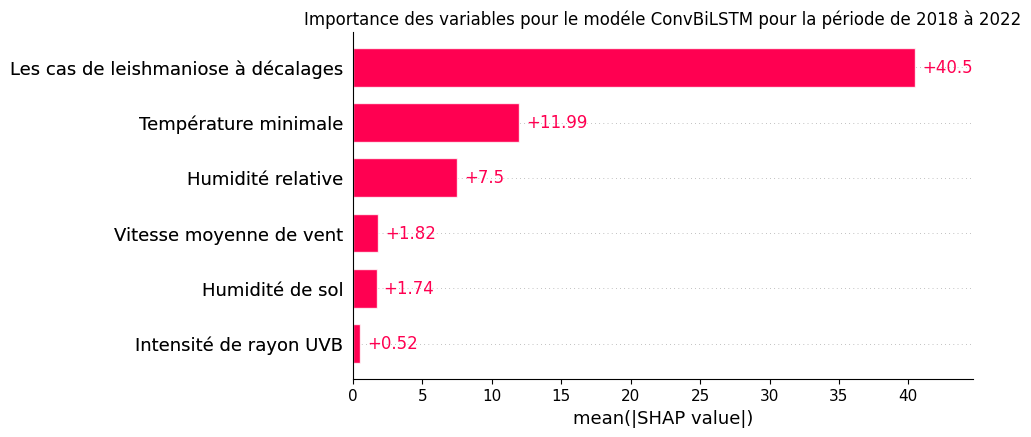

In [ ]:
plt.title("Importance des variables pour le modéle ConvBiLSTM pour la période de 2018 à 2022")
shap.plots.bar(shap_value_object_all(shap_value))